In [ ]:
# Another Sum

In [361]:
import copy
from matplotlib.path import Path as mPath
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from shapely.geometry import Point, Polygon
from shapely.plotting import plot_polygon
import xarray as xr

from scipy.optimize import curve_fit

In [5]:
max_year = 2050

In [6]:
output = pd.read_csv('/home/sallen/MEOPAR/ANALYSIS/analysis-susan/notebooks/Metro/PBDE_99_daily_projected_2030.csv', 
                     parse_dates=[0], header=0, names=['Date', 'PBDE_99'])

In [7]:
output['year'] = output['Date'].dt.year
discharge = output.groupby('year')['PBDE_99'].mean()
discharge[0:5]

year
1970    0.000000
1971    0.000213
1972    0.005138
1973    0.014280
1974    0.027694
Name: PBDE_99, dtype: float64

In [8]:
# Maximum output
max_output = pd.read_csv('PBDEs_max_predicted_discharge.csv', parse_dates=[0], header=0)
max_output['year'] = max_output['Unnamed: 0'].dt.year
discharge = max_output.groupby('year')['BDE-99'].mean()
discharge[0:5]

year
1970    0.000000
1971    0.001926
1972    0.011264
1973    0.023517
1974    0.046056
Name: BDE-99, dtype: float64

In [507]:
# Minimum output
min_output = pd.read_csv('PBDEs_min_predicted_discharge.csv', parse_dates=[0], header=0)
min_output['year'] = min_output['Unnamed: 0'].dt.year
min_discharge = min_output.groupby('year')['BDE-99'].mean()
min_discharge[0:5]

year
1970    0.000000
1971    0.001403
1972    0.008089
1973    0.016617
1974    0.032282
Name: BDE-99, dtype: float64

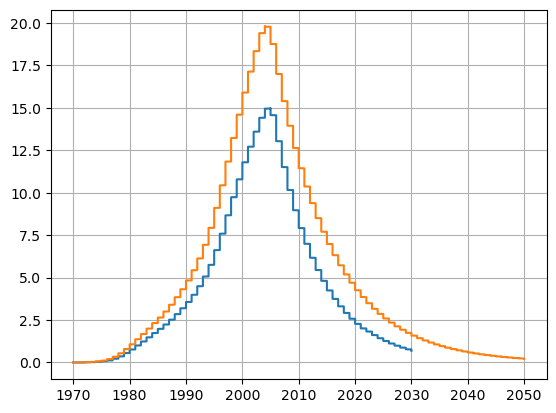

In [9]:
#output['PBDE_99'].plot(x='year');
#max_output['BDE-99'].plot(x='year');
plt.plot(output.year, output['PBDE_99'])
plt.plot(max_output.year, max_output['BDE-99'])
plt.grid();

In [13]:
year1 = xr.open_dataset('Simulation_V4_year_1.nc')
year2 = xr.open_dataset('Simulation_V4_year_2.nc')
year3 = xr.open_dataset('Simulation_V4_year_3.nc')
year4 = xr.open_dataset('Simulation_V4_year_4.nc')
year5 = xr.open_dataset('Simulation_V4_year_5.nc')
year6 = xr.open_dataset('Simulation_V4_year_6.nc')
year7 = xr.open_dataset('Simulation_V4_year_7.nc')
year8 = xr.open_dataset('Simulation_V4_year_8.nc')
year9 = xr.open_dataset('Simulation_V4_year_9.nc')

In [11]:
def pad_year(year3, conversion, ts_full_yr1):
    ts_full_yr3d = (year3.status == 2).sum(axis=0) * conversion
    ts_full_yr3 = np.zeros_like(ts_full_yr1)
    ts_full_yr3[1::2] = ts_full_yr3d
    ts_full_yr3[0] = 0.5 * (ts_full_yr3[1] + ts_full_yr2[-1])
    ts_full_yr3[2::2] = 0.5 * (ts_full_yr3[1:-2:2] + ts_full_yr3[3::2])
    return ts_full_yr3

year1

In [14]:
conversion = 1 / 96 / 1000# 1 g per day = 96 particles, change to kg,
ts_full_yr1 = (year1.status == 2).sum(axis=0) * conversion
ts_full_yr2 = (year2.status == 2).sum(axis=0) * conversion
ts_full_yr3 = pad_year(year3, conversion, ts_full_yr1)
ts_full_yr4 = pad_year(year4, conversion, ts_full_yr1)
ts_full_yr5 = pad_year(year5, conversion, ts_full_yr1)
ts_full_yr6 = pad_year(year6, conversion, ts_full_yr1)
ts_full_yr7 = pad_year(year7, conversion, ts_full_yr1)
ts_full_yr8 = pad_year(year8, conversion, ts_full_yr1)
ts_full_yr9 = pad_year(year9, conversion, ts_full_yr1)

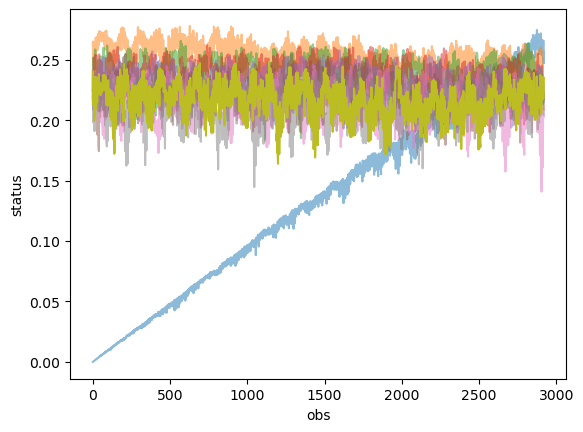

In [15]:
fig, ax = plt.subplots(1, 1)
ts_full_yr1.plot(ax=ax, alpha=0.5);
ts_full_yr2.plot(ax=ax, alpha=0.5);
#ax.plot(np.arange(0, 2920, 2), ts_full_yr3d);
ax.plot(ts_full_yr3, alpha=0.5);
ax.plot(ts_full_yr4, alpha=0.5);
ax.plot(ts_full_yr5, alpha=0.5);
ax.plot(ts_full_yr6, alpha=0.5);
ax.plot(ts_full_yr7, alpha=0.5);
ax.plot(ts_full_yr8, alpha=0.5);
ax.plot(ts_full_yr9);

In [16]:
one_year = 365 * 8
zero_values = np.zeros((max_year-1970+1)*one_year)
one_values = np.zeros_like(zero_values)
two_values = np.zeros_like(zero_values)
three_values = np.zeros_like(zero_values)
four_values = np.zeros_like(zero_values)
five_values = np.zeros_like(zero_values)
six_values = np.zeros_like(zero_values)
seven_values = np.zeros_like(zero_values)
eight_values = np.zeros_like(zero_values)
for year in range(1970, max_year):
    zero_values[(year-1970)*one_year:(year-1970+1)*one_year] = (
        discharge[year] * ts_full_yr1)
for year in range(1971, max_year):
    one_values[(year-1970)*one_year:(year-1970+1)*one_year] = (
        zero_values[(year-1970)*one_year:(year-1970+1)*one_year] + 
        discharge[year-1] * ts_full_yr2)
for year in range(1972, max_year):
    two_values[(year-1970)*one_year:(year-1970+1)*one_year] = (
        one_values[(year-1970)*one_year:(year-1970+1)*one_year] + 
        discharge[year-2] * ts_full_yr3)
for year in range(1973, max_year):
    three_values[(year-1970)*one_year:(year-1970+1)*one_year] = (
        two_values[(year-1970)*one_year:(year-1970+1)*one_year] + 
        discharge[year-3] * ts_full_yr4)
for year in range(1974, max_year):
    four_values[(year-1970)*one_year:(year-1970+1)*one_year] = (
        three_values[(year-1970)*one_year:(year-1970+1)*one_year] + 
        discharge[year-4] * ts_full_yr5)
for year in range(1975, max_year):
    five_values[(year-1970)*one_year:(year-1970+1)*one_year] = (
        four_values[(year-1970)*one_year:(year-1970+1)*one_year] + 
        discharge[year-5] * ts_full_yr6)
for year in range(1976, max_year):
    six_values[(year-1970)*one_year:(year-1970+1)*one_year] = (
        five_values[(year-1970)*one_year:(year-1970+1)*one_year] + 
        discharge[year-6] * ts_full_yr7)
for year in range(1977, max_year):
    seven_values[(year-1970)*one_year:(year-1970+1)*one_year] = (
        six_values[(year-1970)*one_year:(year-1970+1)*one_year] + 
        discharge[year-7] * ts_full_yr8)
for year in range(1978, max_year):
    eight_values[(year-1970)*one_year:(year-1970+1)*one_year] = (
        seven_values[(year-1970)*one_year:(year-1970+1)*one_year] + 
        discharge[year-8] * ts_full_yr9)

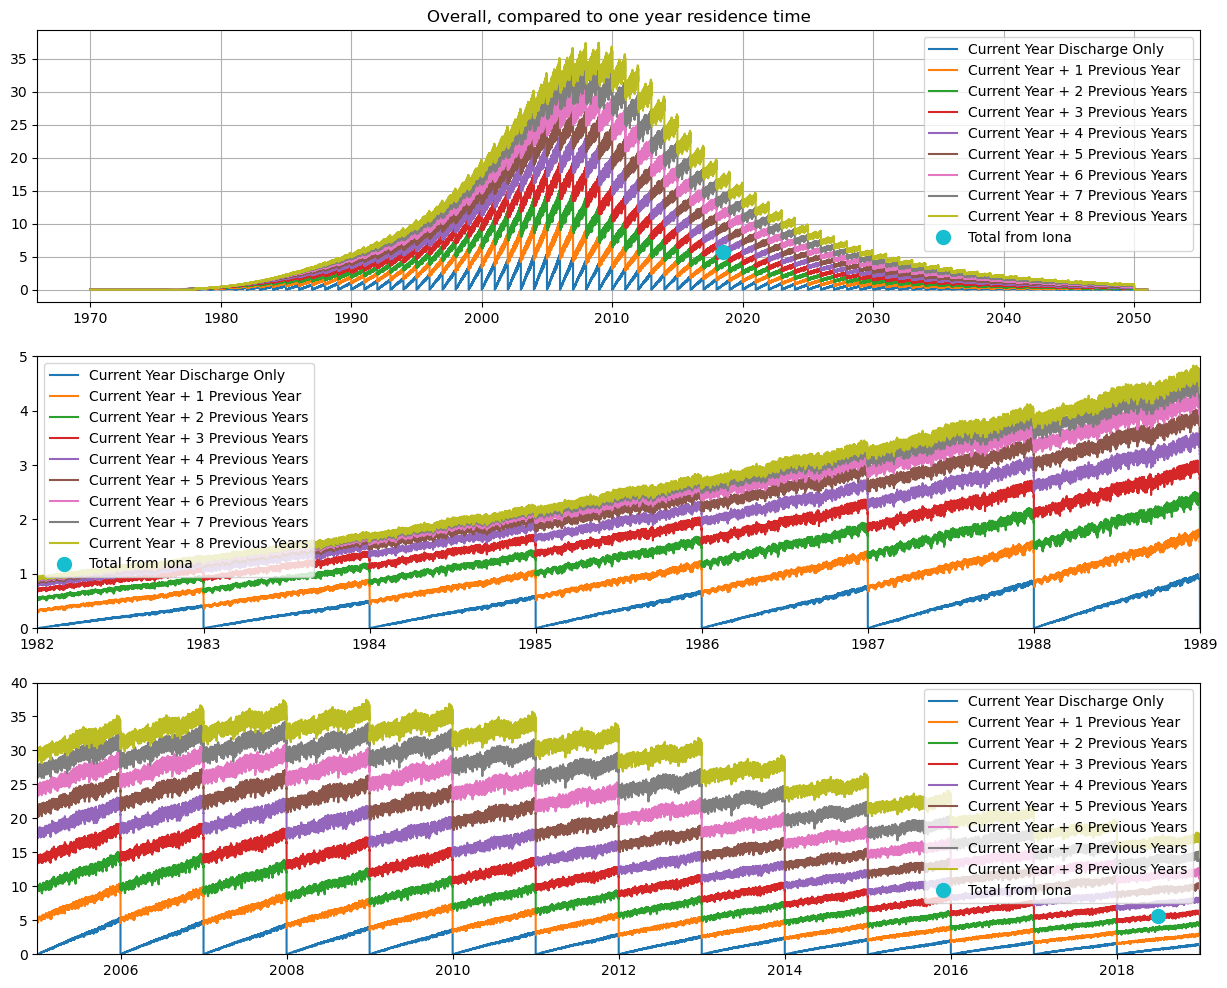

In [19]:
fig, axs = plt.subplots(3, 1, figsize=(15, 12))
for ax in axs:
    ax.plot(np.arange(1970, max_year+1, 1/(8*365)), zero_values, label="Current Year Discharge Only");
    ax.plot(np.arange(1970, max_year+1, 1/(8*365)), one_values, label="Current Year + 1 Previous Year");
    ax.plot(np.arange(1970, max_year+1, 1/(8*365)), two_values, label="Current Year + 2 Previous Years");
    ax.plot(np.arange(1970, max_year+1, 1/(8*365)), three_values, label="Current Year + 3 Previous Years")
    ax.plot(np.arange(1970, max_year+1, 1/(8*365)), four_values, label="Current Year + 4 Previous Years")
    ax.plot(np.arange(1970, max_year+1, 1/(8*365)), five_values, label="Current Year + 5 Previous Years")
    ax.plot(np.arange(1970, max_year+1, 1/(8*365)), six_values, label="Current Year + 6 Previous Years")
    ax.plot(np.arange(1970, max_year+1, 1/(8*365)), seven_values, label="Current Year + 7 Previous Years")
    ax.plot(np.arange(1970, max_year+1, 1/(8*365)), eight_values, label="Current Year + 8 Previous Years")
    ax.plot([2018.5], [71/2.5/5], 'o', markersize=10, label='Total from Iona'); # 2.5 proportion from Iona, 1/5 part from PBDE-99?
    ax.legend();
axs[1].set_xlim(1982, 1989);
axs[1].set_ylim(0, 5);
axs[2].set_xlim(2005, 2019);
axs[2].set_ylim(0, 40);

axs[0].grid();
axs[0].set_title('Overall, compared to one year residence time');

# At Station S4-1.5 #

In [20]:
def def_poly(mask):
    # boxes from Vicente: Regions_functions_V2.py
    # Southern Strait: Subregion
    Sx1_1, Sy1_1 = [202, 292], [505, 505]
    Sx1_4, Sy1_4 = [238, 245], [465, 410]
    Sx1_5, Sy1_5 = [302, 280], [410, 470]

    (S1_lon_1, S1_lat_1) = ([mask.nav_lon[Sy1_1[0],Sx1_1[0]].values, mask.nav_lon[Sy1_1[1],Sx1_1[1]].values], 
                            [mask.nav_lat[Sy1_1[0],Sx1_1[0]].values, mask.nav_lat[Sy1_1[1],Sx1_1[1]].values])
    (S1_lon_4, S1_lat_4) = ([mask.nav_lon[Sy1_4[0],Sx1_4[0]].values, mask.nav_lon[Sy1_4[1],Sx1_4[1]].values], 
                            [mask.nav_lat[Sy1_4[0],Sx1_4[0]].values, mask.nav_lat[Sy1_4[1],Sx1_4[1]].values])
    (S1_lon_5, S1_lat_5) = ([mask.nav_lon[Sy1_5[0],Sx1_5[0]].values, mask.nav_lon[Sy1_5[1],Sx1_5[1]].values], 
                            [mask.nav_lat[Sy1_5[0],Sx1_5[0]].values, mask.nav_lat[Sy1_5[1],Sx1_5[1]].values])

    polygon_lon_lat_S1 = [
    (S1_lon_1[0], S1_lat_1[0]),
    (S1_lon_1[1], S1_lat_1[1]),
    (S1_lon_5[1], S1_lat_5[1]),
    (S1_lon_4[0], S1_lat_4[0])
    ]
    polygon_coors_S1 = Polygon(polygon_lon_lat_S1)
    polygon_path_S1 = mPath(polygon_lon_lat_S1)
    

    return polygon_coors_S1, polygon_path_S1

In [21]:
def find_poly_volume(mask, bathy, top_depth):
    polygon_coors_S1, polygon_path_S1 = def_poly(mask)

    my_mask_S = np.zeros((898, 398))

    # just subset to make it run faster
    for ii in range(400, 510):
        for jj in range (200, 310):
            if (Point(bathy.nav_lon[ii, jj].values, bathy.nav_lat[ii, jj].values)).within(polygon_coors_S1):
                my_mask_S[ii, jj] = 1

    volume_S = mask.tmask[0] * my_mask_S * mask.e1t[0] * mask.e2t[0] * mask.e3t_0[0]
    return polygon_coors_S1, polygon_path_S1, volume_S[top_depth:].sum()

In [22]:
bathy = xr.open_dataset('/home/sallen/MEOPAR/grid/bathymetry_202108.nc')
mask = xr.open_dataset('/home/sallen/MEOPAR/grid/mesh_mask202108.nc')
top_depth = 24

In [23]:
polygon_coors_S1, polygon_path_S1, volume_S = find_poly_volume(mask, bathy, top_depth)

In [24]:
def count_S1_values(yearn, nobs, skip, top_depth, mask, polygon_path_S1):

    count = np.zeros((nobs))
    
    status_mask = yearn.status[::skip] == 2
    depth_mask = yearn.z[::skip] > mask.gdepw_1d[0, top_depth]
    lat_mask = (yearn.lat[::skip] > 49.1485) & (yearn.lat[::skip] < 49.4075)
    lon_mask = (yearn.lon[::skip] > -124.0322) & (yearn.lon[::skip] < -123.5103)

    lats = np.ma.masked_array(yearn.lat[::skip], 
                              mask=1 - status_mask * depth_mask * lat_mask * lon_mask)
    lons = np.ma.masked_array(yearn.lon[::skip], 
                              mask = 1 - status_mask * depth_mask * lat_mask * lon_mask)

    for it in range(nobs):
        points = np.stack([lons[:, it].compressed(), lats[:, it].compressed()]).transpose()
        count[it] = polygon_path_S1.contains_points(points).sum()

    return count

In [ ]:
ntraj, nobs = year1.status.values.shape
skip = 1
count = count_S1_values(year1, nobs, skip, top_depth, mask, polygon_path_S1)

plt.plot(count)
print (f'For skip of {skip}, maximum counts are {count.max()}')

In [ ]:
np.savetxt('S1_counts_year1.txt', count)

In [25]:
year1.close()

In [ ]:
count = count_S1_values(year2, nobs, skip, top_depth, mask, polygon_path_S1)

plt.plot(count)
print (f'For year 2, skip of {skip}, maximum counts are {count.max()}')
np.savetxt('S1_counts_year2.txt', count)

In [26]:
year2.close()

In [ ]:
countd = count_S1_values(year3, 1460, skip, top_depth, mask, polygon_path_S1)

In [ ]:
plt.plot(countd)
print (f'For year 3, skip of {skip}, maximum counts are {countd.max()}')
np.savetxt('S1_counts_year3.txt', countd)

In [27]:
year3.close()

In [ ]:
countd = count_S1_values(year4, 1460, skip, top_depth, mask, polygon_path_S1)

In [ ]:
plt.plot(countd)
print (f'For year 3, skip of {skip}, maximum counts are {countd.max()}')
np.savetxt('S1_counts_year4.txt', countd)

In [28]:
year4.close()

In [ ]:
countd = count_S1_values(year5, 1460, 1, top_depth, mask, polygon_path_S1)

In [ ]:
plt.plot(countd)
print (f'For year 5, skip of {1}, maximum counts are {countd.max()}')
np.savetxt('S1_counts_year5.txt', countd)

In [29]:
year5.close()

In [25]:
countd = count_S1_values(year6, 1460, 1, top_depth, mask, polygon_path_S1)

For year 6, maximum counts are 2264.0


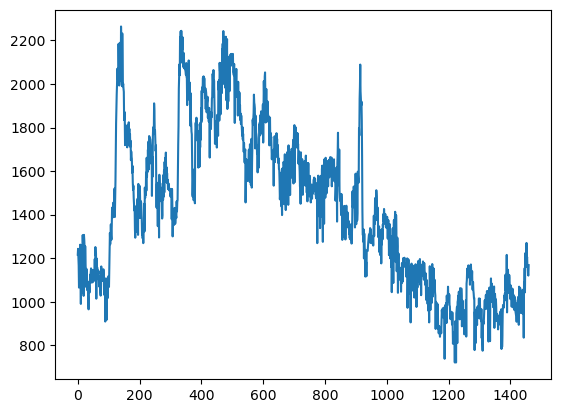

In [26]:
plt.plot(countd)
print (f'For year 6, maximum counts are {countd.max()}')
np.savetxt('S1_counts_year6.txt', countd)

In [30]:
year6.close()

In [26]:
countd = count_S1_values(year7, 1460, 1, top_depth, mask, polygon_path_S1)

For year 7, maximum counts are 1261.0


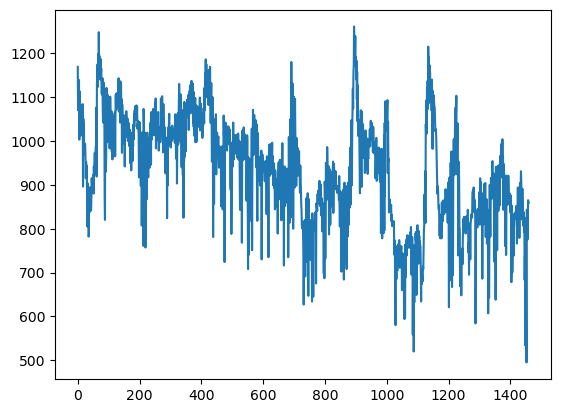

In [27]:
plt.plot(countd)
print (f'For year 7, maximum counts are {countd.max()}')
np.savetxt('S1_counts_year7.txt', countd)

In [31]:
year7.close()

In [27]:
countd = count_S1_values(year8, 1460, 1, top_depth, mask, polygon_path_S1)

For year 8, maximum counts are 1940.0


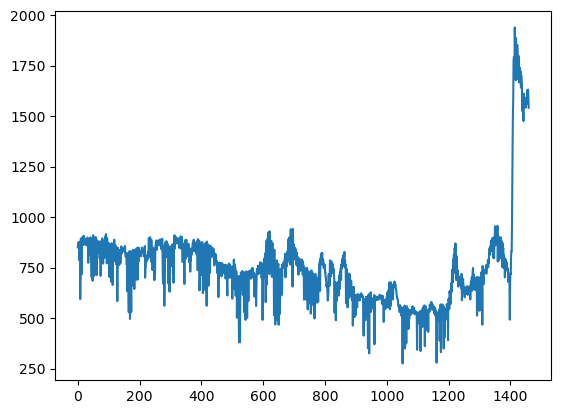

In [28]:
plt.plot(countd)
print (f'For year 8, maximum counts are {countd.max()}')
np.savetxt('S1_counts_year8.txt', countd)

In [32]:
year8.close()

In [33]:
countd = count_S1_values(year9, 1460, 1, top_depth, mask, polygon_path_S1)

For year 9, maximum counts are 1751.0


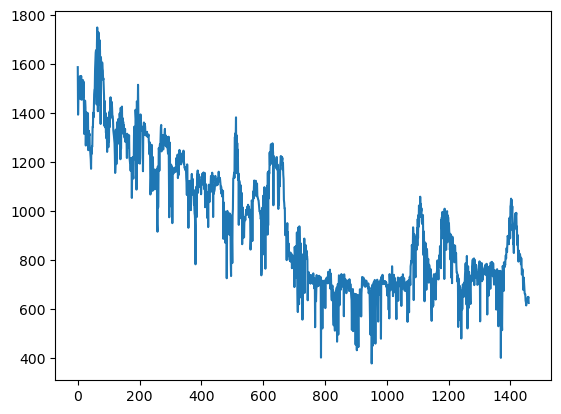

In [34]:
plt.plot(countd)
print (f'For year 9, maximum counts are {countd.max()}')
np.savetxt('S1_counts_year9.txt', countd)

In [35]:
year9.close()

In [36]:
def pad_S1 (count_y1, count_y2, count_y3d):
    count_y3 = np.zeros_like(count_y1)
    count_y3[1::2] = count_y3d
    count_y3[0] = 0.5 * (count_y3[1] + count_y2[-1])
    count_y3[2::2] = 0.5 * (count_y3[1:-2:2] + count_y3[3::2])
    return count_y3

In [37]:
count_y1 = np.loadtxt('S1_counts_year1.txt')
count_y2 = np.loadtxt('S1_counts_year2.txt')
count_y3d = np.loadtxt('S1_counts_year3.txt')
count_y3 = pad_S1(count_y1, count_y2, count_y3d)
count_y4d = np.loadtxt('S1_counts_year4.txt')
count_y4 = pad_S1(count_y1, count_y3, count_y4d)
count_y5d = np.loadtxt('S1_counts_year5.txt')
count_y5 = pad_S1(count_y1, count_y4, count_y5d)
count_y6d = np.loadtxt('S1_counts_year6.txt')
count_y6 = pad_S1(count_y1, count_y5, count_y6d)
count_y7d = np.loadtxt('S1_counts_year7.txt')
count_y7 = pad_S1(count_y1, count_y6, count_y7d)
count_y8d = np.loadtxt('S1_counts_year8.txt')
count_y8 = pad_S1(count_y1, count_y7, count_y8d)
count_y9d = np.loadtxt('S1_counts_year9.txt')
count_y9 = pad_S1(count_y1, count_y8, count_y9d)

In [38]:
print (count_y1.shape, count_y5.shape)
volume_S

(2920,) (2920,)


<xarray.DataArray ()> Size: 8B
array(1.09140927e+11)

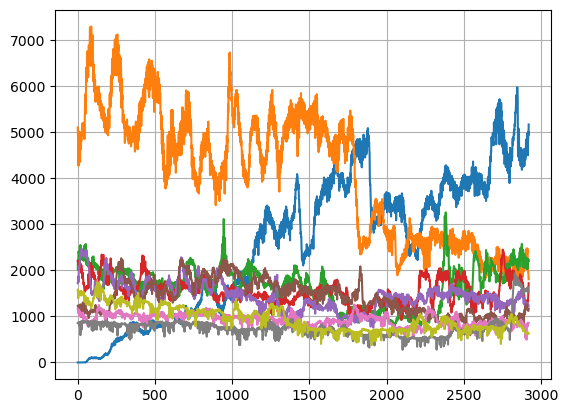

In [42]:
plt.plot(count_y1)
plt.plot(count_y2)
plt.plot(count_y3)
plt.plot(count_y4)
plt.plot(count_y5)
plt.plot(count_y6)
plt.plot(count_y7)
plt.plot(count_y8)
plt.plot(count_y9)
plt.grid()

In [45]:
one_year = 365 * 8
zero_values = np.zeros((max_year-1970+1)*one_year)
one_values = np.zeros_like(zero_values)
two_values = np.zeros_like(zero_values)
three_values = np.zeros_like(zero_values)
four_values = np.zeros_like(zero_values)
five_values = np.zeros_like(zero_values)
six_values = np.zeros_like(zero_values)
seven_values = np.zeros_like(zero_values)
eight_values = np.zeros_like(zero_values)

for year in range(1970, max_year):
    zero_values[(year-1970)*one_year:(year-1970+1)*one_year] = (
        discharge[year] * count_y1 * conversion / volume_S.values)
for year in range(1971, max_year):
    one_values[(year-1970)*one_year:(year-1970+1)*one_year] = (
        zero_values[(year-1970)*one_year:(year-1970+1)*one_year] + 
        discharge[year-1] * count_y2 * conversion / volume_S.values)
for year in range(1972, max_year):
    two_values[(year-1970)*one_year:(year-1970+1)*one_year] = (
        one_values[(year-1970)*one_year:(year-1970+1)*one_year] + 
        discharge[year-2] * count_y3 * conversion / volume_S.values)
for year in range(1973, max_year):
    three_values[(year-1970)*one_year:(year-1970+1)*one_year] = (
        two_values[(year-1970)*one_year:(year-1970+1)*one_year] + 
        discharge[year-3] * count_y4 * conversion / volume_S.values)
for year in range(1974, max_year):
    four_values[(year-1970)*one_year:(year-1970+1)*one_year] = (
        three_values[(year-1970)*one_year:(year-1970+1)*one_year] + 
        discharge[year-4] * count_y5 * conversion / volume_S.values)
for year in range(1975, max_year):
    five_values[(year-1970)*one_year:(year-1970+1)*one_year] = (
        four_values[(year-1970)*one_year:(year-1970+1)*one_year] + 
        discharge[year-5] * count_y6 * conversion / volume_S.values)
for year in range(1976, max_year):
    six_values[(year-1970)*one_year:(year-1970+1)*one_year] = (
        five_values[(year-1970)*one_year:(year-1970+1)*one_year] + 
        discharge[year-6] * count_y7 * conversion / volume_S.values)
for year in range(1977, max_year):
    seven_values[(year-1970)*one_year:(year-1970+1)*one_year] = (
        six_values[(year-1970)*one_year:(year-1970+1)*one_year] + 
        discharge[year-7] * count_y8 * conversion / volume_S.values)
for year in range(1978, max_year):
    eight_values[(year-1970)*one_year:(year-1970+1)*one_year] = (
        seven_values[(year-1970)*one_year:(year-1970+1)*one_year] + 
        discharge[year-8] * count_y9 * conversion / volume_S.values)

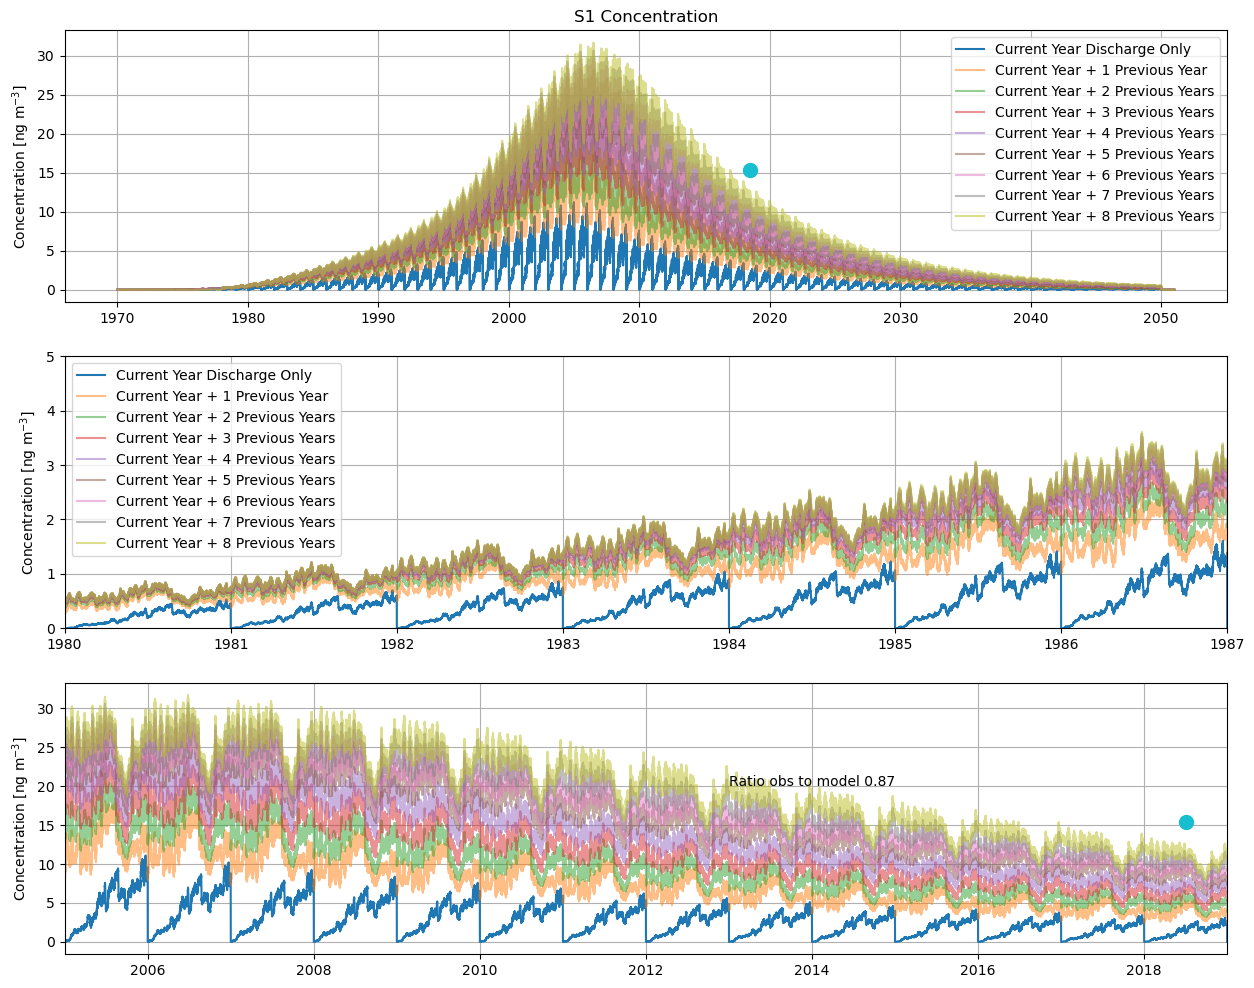

In [46]:
fig, axs = plt.subplots(3, 1, figsize=(15, 12))
for ax in axs:
    ax.plot(np.arange(1970, max_year+1, 1/(8*365)), zero_values*1e12, label="Current Year Discharge Only");
    ax.plot(np.arange(1970, max_year+1, 1/(8*365)), one_values*1e12, label="Current Year + 1 Previous Year", 
            alpha=0.5);
    ax.plot(np.arange(1970, max_year+1, 1/(8*365)), two_values*1e12, label="Current Year + 2 Previous Years", 
            alpha=0.5);
    ax.plot(np.arange(1970, max_year+1, 1/(8*365)), three_values*1e12, label="Current Year + 3 Previous Years", 
            alpha=0.5)
    ax.plot(np.arange(1970, max_year+1, 1/(8*365)), four_values*1e12, label="Current Year + 4 Previous Years", 
            alpha=0.5)
    ax.plot(np.arange(1970, max_year+1, 1/(8*365)), five_values*1e12, label="Current Year + 5 Previous Years", 
            alpha=0.5)
    ax.plot(np.arange(1970, max_year+1, 1/(8*365)), six_values*1e12, label="Current Year + 6 Previous Years", 
            alpha=0.5)
    ax.plot(np.arange(1970, max_year+1, 1/(8*365)), seven_values*1e12, label="Current Year + 7 Previous Years", 
            alpha=0.5)
    ax.plot(np.arange(1970, max_year+1, 1/(8*365)), eight_values*1e12, label="Current Year + 8 Previous Years", 
            alpha=0.5)
    ax.set_ylabel('Concentration [ng m$^{-3}$]')
    if ax != axs[2]:
        ax.legend()
    ax.grid()
    ax.plot([2018.5], [(70.2-31.9)/2.5], 'o', markersize=10, label='Minimum Expected from Iona')
axs[1].set_xlim(1980, 1987)
axs[1].set_ylim(0, 5)
axs[2].set_xlim(2005, 2019)
#axs[2].set_ylim(0, 2);


axs[0].set_title('S1 Concentration');
axs[2].text(2013, 20, f'Ratio obs to model {eight_values[(2018-1970)*8*365:(2019-1970)*8*365].max()*1e12/((70.2-31.9)/2.5):.2f}');

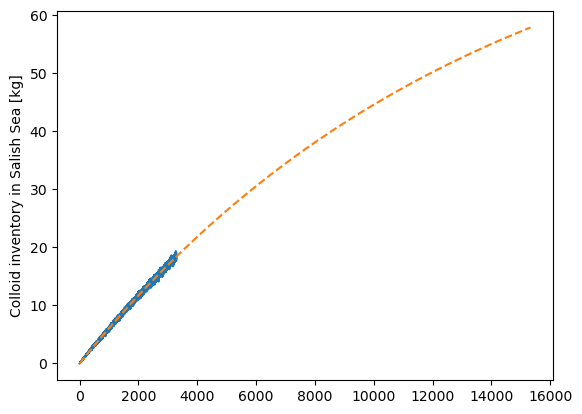

In [52]:
full_ts = np.zeros((2920*9))
full_ts[0:2920] = ts_full_yr1 * discharge[2018-5]
full_ts[2920:2920*2] = (ts_full_yr1 + ts_full_yr2) * discharge[2018-5]
full_ts[2920*2:2920*3] = (ts_full_yr1 + ts_full_yr2 + ts_full_yr3) * discharge[2018-5]
full_ts[2920*3:2920*4] = (ts_full_yr1 + ts_full_yr2 + ts_full_yr3 + ts_full_yr4) * discharge[2018-5]
full_ts[2920*4:2920*5] = (ts_full_yr1 + ts_full_yr2 + ts_full_yr3 + ts_full_yr4 + ts_full_yr5) * discharge[2018-5]
full_ts[2920*5:2920*6] = (ts_full_yr1 + ts_full_yr2 + ts_full_yr3 + ts_full_yr4 + ts_full_yr5 +
                   ts_full_yr6) * discharge[2018-5]
full_ts[2920*6:2920*7] = (ts_full_yr1 + ts_full_yr2 + ts_full_yr3 + ts_full_yr4 + ts_full_yr5 +
                   ts_full_yr6 + ts_full_yr7) * discharge[2018-5] 
full_ts[2920*7:2920*8] = (ts_full_yr1 + ts_full_yr2 + ts_full_yr3 + ts_full_yr4 + ts_full_yr5 +
                   ts_full_yr6 + ts_full_yr7 + ts_full_yr8) * discharge[2018-5] 
full_ts[2920*8:2920*9] = (ts_full_yr1 + ts_full_yr2 + ts_full_yr3 + ts_full_yr4 + ts_full_yr5 +
                   ts_full_yr6 + ts_full_yr7 + ts_full_yr8 + ts_full_yr9) * discharge[2018-5] 

plt.plot(np.arange(2920*9)*365/2920, full_ts)
plt.plot(np.arange(2920*6)*365/2920*7, curve(np.arange(2920*6)*365/2920*7, popt[0], popt[1]), '--')
plt.ylabel('Colloid inventory in Salish Sea [kg]');

In [48]:
def curve(t, goal, decay):
    return goal * (1. - np.exp(-t/decay))

In [80]:
def curve_double(t, goal, split, decay1, decay2):
    return goal * (1. - split* np.exp(-t/decay1) - (1-split) * np.exp(-t/decay2))

In [103]:
def curve_seasonal(t, goal, decay, cos, sin):
    return goal * (1. - np.exp(-t/decay)) * (1 + cos*np.cos(2*np.pi*t/365) + sin*np.sin(2*np.pi*t/365))

In [50]:
popt, pcov = curve_fit(curve, np.arange(2920*9)*365/2920, full_ts, p0=[14, 365])

In [51]:
popt[0], popt[1]/365

(85.5644466832481, 37.21310264426866)

Two years: (17.41713421464484, 10.90945107682955)  
Three years: (24.445575662553964, 15.61734887155874)   
Four years: (52.29210399365346, 22.076422763801034)    
Five years: (64.38985900764096, 27.49056757638026)   
Six years: (71.48116512896779, 30.69737871444027)  
Seven years: (74.16891822752056, 31.923966756719608)  
Eight years: (78.1165756920782, 33.74740460337156)  
Nine years: (85.5644466832481, 37.21310264426866)  

1.301830747196212
1.1615045076960269
0.9514522060677417


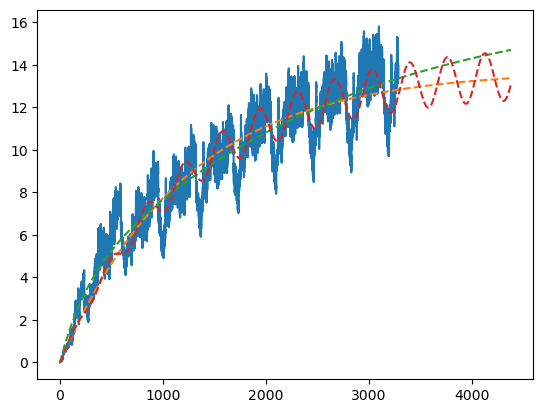

In [108]:
S1_ts = np.zeros((2920*9))
S1_ts[0:2920] = count_y1 * conversion / volume_S.values * 1e12 * discharge[2018-5]
S1_ts[2920:2920*2] = (count_y1 + count_y2) * conversion / volume_S.values * 1e12 * discharge[2018-5]
S1_ts[2920*2:2920*3] = (count_y1 + count_y2 + count_y3) * conversion / volume_S.values * 1e12 * discharge[2018-5]
S1_ts[2920*3:2920*4] = (count_y1 + count_y2 + count_y3 + count_y4) * conversion / volume_S.values * 1e12 * discharge[2018-5]
S1_ts[2920*4:2920*5] = (count_y1 + count_y2 + count_y3 + count_y4 + count_y5) * conversion / volume_S.values * 1e12 * discharge[2018-5]
S1_ts[2920*5:2920*6] = (count_y1 + count_y2 + count_y3 + count_y4 + count_y5 +
                       count_y6) * conversion / volume_S.values * 1e12 * discharge[2018-5]
S1_ts[2920*6:2920*7] = (count_y1 + count_y2 + count_y3 + count_y4 + count_y5 +
                       count_y6 + count_y7) * conversion / volume_S.values * 1e12 * discharge[2018-5]
S1_ts[2920*7:2920*8] = (count_y1 + count_y2 + count_y3 + count_y4 + count_y5 +
                       count_y6 + count_y7 + count_y8) * conversion / volume_S.values * 1e12 * discharge[2018-5]
S1_ts[2920*8:2920*9] = (count_y1 + count_y2 + count_y3 + count_y4 + count_y5 +
                       count_y6 + count_y7 + count_y8 + count_y9) * conversion / volume_S.values * 1e12 * discharge[2018-5]


plt.plot(np.arange(2920*9)*365/2920, S1_ts)
plt.plot(np.arange(2920*6)*365/2920*2, curve(np.arange(2920*6)*365/2920*2, poptS[0], poptS[1]), '--');
plt.plot(np.arange(2920*6)*365/2920*2, curve_double(np.arange(2920*6)*365/2920*2, poptS2[0], poptS2[1], poptS2[2], poptS2[3]), '--');
plt.plot(np.arange(2920*6)*365/2920*2, curve_seasonal(np.arange(2920*6)*365/2920*2, poptsea[0], poptsea[1], poptsea[2], poptsea[3]), '--');
print (((curve(np.arange(2920*9)*365/2920, poptS[0], poptS[1]) - S1_ts)**2).mean())
print (((curve_double(np.arange(2920*9)*365/2920, poptS2[0], poptS2[1], poptS2[2], poptS2[3]) - S1_ts)**2).mean())
print (((curve_seasonal(np.arange(2920*9)*365/2920, poptsea[0], poptsea[1], poptsea[2], poptsea[3]) - S1_ts)**2).mean())

In [58]:
poptS, pcovS = curve_fit(curve, np.arange(2920*9)*365/2920, S1_ts, p0=[14, 365])

In [59]:
poptS[0], poptS[1]/365

(13.740191293469891, 3.3121557060125633)

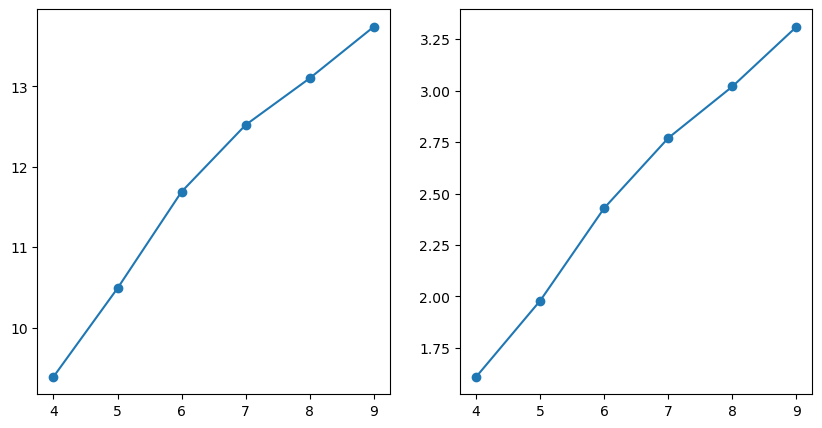

In [72]:
array1 = np.array([4, 5, 6, 7, 8, 9])
array2 = np.array([9.39, 10.49, 11.69, 12.52, 13.10, 13.74])
array3 = np.array([1.61, 1.98, 2.43, 2.77, 3.02, 3.31])
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].plot(array1, array2, '-o')
axs[1].plot(array1, array3, '-o');

In [81]:
poptS2, pcovS2 = curve_fit(curve_double, np.arange(2920*9)*365/2920, S1_ts, p0=[14, 0.5, 365, 5*365])

In [82]:
poptS2

array([1.71466361e+01, 1.78410223e-01, 2.33529191e+02, 2.49853497e+03])

Two years: 5.329101814691215, 1.2955400430965205)  
Three years: (5.478982494839365, 1.3371411556610349)  
Four years: (6.097803282826282, 1.6150681163900362)  
Four years with maximum output: (9.396547564976244, 1.615069864192495)  
Five years: (10.493062550356187, 1.9832679109632088)  
Six years: (11.69404723881173, 2.4313623883482416)  
Seven years: (12.526726307246445, 2.7680132681968566)   
Eight years: (13.107590702545492, 3.0198147202556767)  
Nine years: (13.740191293469891, 3.3121557060125633)  

In [115]:
poptsea, pcovsea = curve_fit(curve_seasonal, np.arange(2920*9)*365/2920, S1_ts, p0=[14, 3*365, 0.2, 0.2])
poptsea[0]/discharge[2018-5], poptsea[1]/365, poptsea[2], poptsea[3] 

(1.552741620648133,
 3.3820981891671065,
 -0.029598909149556915,
 0.08080695008194456)

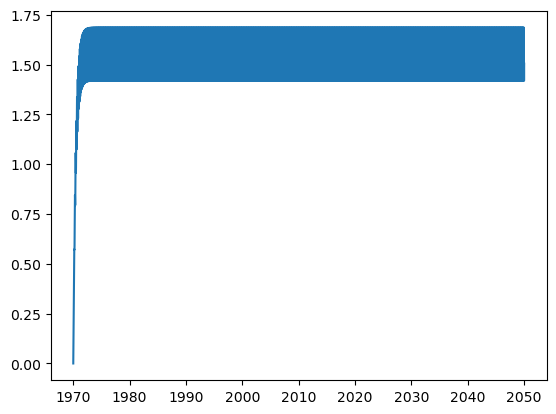

In [121]:
S1_estimate = np.zeros((2920*(max_year-1970)))
S1_estimate = curve_seasonal(np.arange((max_year-1970)*2920), poptsea[0]/discharge[2018-5], poptsea[1], poptsea[2], poptsea[3])
plt.plot(np.arange(1970, max_year, 1/2920), S1_estimate)

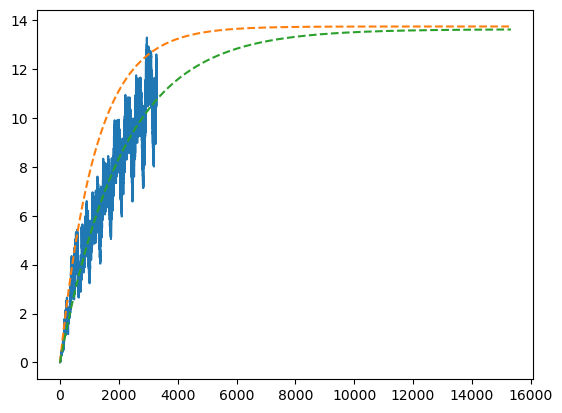

In [65]:
S1_ats = np.zeros((2920*9))
S1_ats[0:2920] = count_y1 * conversion / volume_S.values * 1e12 * discharge[2018]
S1_ats[2920:2920*2] = ((count_y1 * discharge[2018] + count_y2 * discharge[2018-1]) 
                       * conversion / volume_S.values * 1e12)
S1_ats[2920*2:2920*3] = ((count_y1  * discharge[2018] + count_y2 * discharge[2018-1]
                        + count_y3 * discharge[2018-2]) 
                        * conversion / volume_S.values * 1e12)
S1_ats[2920*3:2920*4] = ((count_y1  * discharge[2018] + count_y2 * discharge[2018-1]
                        + count_y3 * discharge[2018-2] + count_y4 * discharge[2018-3]) 
                         * conversion / volume_S.values * 1e12)
S1_ats[2920*4:2920*5] = ((count_y1  * discharge[2018] + count_y2 * discharge[2018-1]
                        + count_y3 * discharge[2018-2] + count_y4 * discharge[2018-3]
                          + count_y5 * discharge[2018-4]) 
                         * conversion / volume_S.values * 1e12)
S1_ats[2920*5:2920*6] = ((count_y1  * discharge[2018] + count_y2 * discharge[2018-1]
                        + count_y3 * discharge[2018-2] + count_y4 * discharge[2018-3]
                          + count_y5 * discharge[2018-4] + count_y6 * discharge[2018-5]) 
                         * conversion / volume_S.values * 1e12)
S1_ats[2920*6:2920*7] = ((count_y1  * discharge[2018] + count_y2 * discharge[2018-1]
                        + count_y3 * discharge[2018-2] + count_y4 * discharge[2018-3]
                          + count_y5 * discharge[2018-4] + count_y6 * discharge[2018-5]
                           + count_y7 * discharge[2018-6]) 
                          * conversion / volume_S.values * 1e12)
S1_ats[2920*7:2920*8] = ((count_y1  * discharge[2018] + count_y2 * discharge[2018-1]
                        + count_y3 * discharge[2018-2] + count_y4 * discharge[2018-3]
                          + count_y5 * discharge[2018-4] + count_y6 * discharge[2018-5]
                           + count_y7 * discharge[2018-6] + count_y8 * discharge[2018-7]) 
                          * conversion / volume_S.values * 1e12)
S1_ats[2920*8:2920*9] = ((count_y1  * discharge[2018] + count_y2 * discharge[2018-1]
                        + count_y3 * discharge[2018-2] + count_y4 * discharge[2018-3]
                          + count_y5 * discharge[2018-4] + count_y6 * discharge[2018-5]
                           + count_y7 * discharge[2018-6] + count_y8 * discharge[2018-7]
                         + count_y9 * discharge[2018-8]) 
                          * conversion / volume_S.values * 1e12)

plt.plot(np.arange(2920*9)*365/2920, S1_ats)
plt.plot(np.arange(2920*6)*365/2920*7, curve(np.arange(2920*6)*365/2920*7, poptS[0], poptS[1]), '--');
plt.plot(np.arange(2920*6)*365/2920*7, curve(np.arange(2920*6)*365/2920*7, poptA[0], poptA[1]), '--');

In [62]:
print (discharge[2018-8], discharge[2018-7], discharge[2018-6])

12.032128573066498 10.900011148330556 9.873101486533647


In [63]:
poptA, pcovA = curve_fit(curve, np.arange(2920*9)*365/2920, S1_ats, p0=[14, 365])

In [64]:
poptA[0], poptA[1]/365, curve((2920*9)*365/2920, poptA[0], poptA[1])

(13.626472330075835, 5.78770603508937, 10.748764282723188)

Nine years: (13.626472330075835, 5.78770603508937)  
Eight years: (12.223694625475773, 4.901715481676744)  
Seven years: (11.247256877353259, 4.314067614338212)  
Six years: (9.92605351553952, 3.5562707558738094)  
Five years: (8.165630147115492, 2.6000593498446687)  
Four years: (6.8282377661141025, 1.9321300372077967)  
Three years: (5.807029829608813, 1.4830915217713971)  
Two years: (5.440814566321849, 1.3730702836266593)  
One year: (4.137721316403167, 1.1495851221292923)  

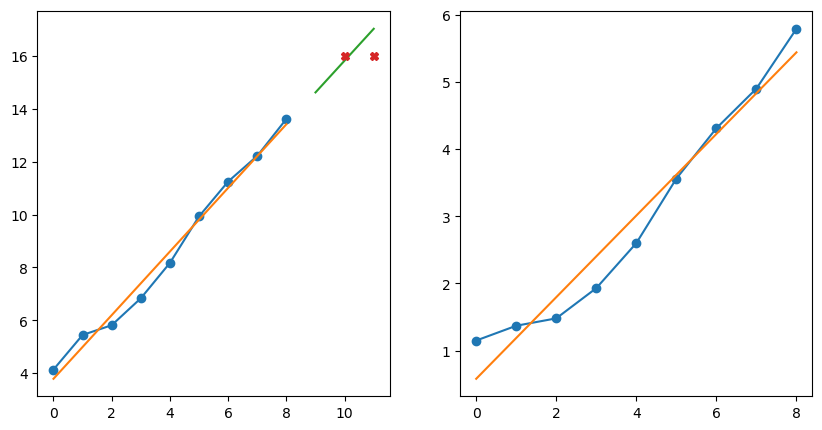

In [70]:
array1 = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8])
array2 = np.array([4.13, 5.44, 5.81, 6.83, 8.17, 9.93, 11.25, 12.22, 13.62])
array3 = np.array([1.15, 1.37, 1.48, 1.93, 2.60, 3.56, 4.31, 4.90, 5.79])
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].plot(array1, array2, '-o')
axs[0].plot(array1, mx[0]*array1+mx[1], '-')
axs[1].plot(array1, array3, '-o');
axs[1].plot(array1, mx2[0]*array1+mx2[1], '-')
axs[0].plot([9, 10, 11], mx[0]*np.array([9, 10, 11])+mx[1], '-')
axs[0].plot([10, 11], [16, 16], 'X');

In [67]:
def myline(t, m, b):
    return m*t + b

In [68]:
mx, stuff = curve_fit(myline, array1, array2, p0=[1, 4])

In [69]:
mx2, stuff = curve_fit(myline, array1, array3, p0=[0.6, 1])

In [ ]:
mx2

## Work on Extrapolation ##

In [127]:
tseries = np.concatenate([count_y1, count_y2, count_y3,
                          count_y4, count_y5, count_y6,
                          count_y7, count_y8, count_y9,])* conversion / volume_S.values * 1e12

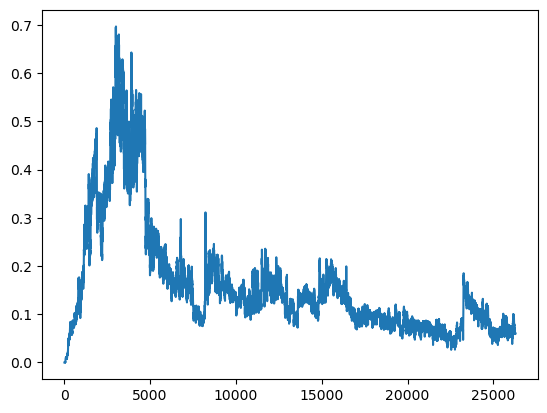

In [454]:
plt.plot(tseries);

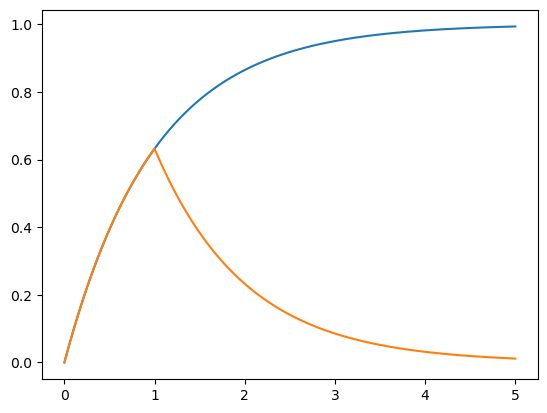

In [455]:
# theoretical integrated curves for steady output, forever and for one day, with single decay
tmax = 1
trange = np.arange(0, 5, 1/2920)
plt.plot(np.arange(0, 5, 1/2920), 1 - np.exp(-trange))
plt.plot(np.arange(0, 5, 1/2920), np.exp(-trange)*(np.exp(np.minimum(trange, tmax)) -1));

In [286]:
# Try fitting the curve now
def curve_single_day(trange, maxv, decay, delay, tmax=1):
    t = trange - delay
    value = maxv * np.exp(-t/decay) * (np.exp(np.minimum(t, tmax)/decay) - 1)
    return value

In [287]:
fit_single_day, cov = curve_fit(curve_single_day, np.arange(0, 9, 1/2920), tseries, p0=[0.6, 3, 0.1])
fit_single_day

array([ 1.51546472,  3.11620472, -0.06651095])

In [462]:
# not great, negative delay! over all magnitude 1.5 with 3 day delay

In [288]:
print (((curve_single_day(np.arange(0, 9, 1/2920), fit_single_day[0], fit_single_day[1], fit_single_day[2]) - tseries)**2).mean())

0.004105547230316369


In [456]:
# try 2
def curve_double_day_wd(trange, maxv1, maxv2, decay1, decay2, delay, tmax=1):
    t = trange - delay
    tmm = tmax + delay
    value = maxv1 * np.exp(-t/decay1) * (np.exp(np.minimum(t, tmm)/decay1) - 1)
    value = value + maxv2 * np.exp(-t/decay2) * (np.exp(np.minimum(t, tmm)/decay2) - 1)
    value[t<0] = 0
    return value

In [458]:
fit_double_day_wd, cov = curve_fit(curve_double_day_wd, np.arange(0, 9, 1/2920), tseries, p0=[0.6, 0.3, 2, 5, 0.1])
fit_double_day_wd

array([0.32643402, 1.31095168, 0.15646328, 7.95419073, 0.25338982])

In [465]:
# really nice fit.  0.33 units decaying over 0.16 years (distribution)  
# and 1.31 units decying over 8 years (loss of Salish Sea)
# and a quarter of a year to get to S1 (a bit long that)

In [459]:
print (((curve_double_day_wd(np.arange(0, 9, 1/2920), 
                             fit_double_day_wd[0], fit_double_day_wd[1], fit_double_day_wd[2], fit_double_day_wd[3], fit_double_day_wd[4]) 
         - tseries[skip:])**2).mean())

0.0016317476398663815


In [460]:
# try 3, no delay because stacking delay isn't working for me.
def curve_double_day(t, maxv1, maxv2, decay1, decay2, tmm=1):
    value = maxv1 * np.exp(-t/decay1) * (np.exp(np.minimum(t, tmm)/decay1) - 1)
    value = value + maxv2 * np.exp(-t/decay2) * (np.exp(np.minimum(t, tmm)/decay2) - 1)
    return value

In [461]:
fit_double_day, cov = curve_fit(curve_double_day, np.arange(0, 9, 1/2920), tseries, p0=[0.6, 0.3, 2, 5])
fit_double_day

array([ 0.50697685,  1.98789182,  0.87255098, 12.40521322])

In [466]:
# good fit here.  0.51 units decaying over 0.87 years (distribution)
# and 2 units decaying over 12.4 years (loss of Salish Sea)  
# all values make okay sense

In [478]:
skip=0
print (((curve_double_day(np.arange(skip/2920, 9, 1/2920), fit_double_day[0], fit_double_day[1], fit_double_day[2], fit_double_day[3]) 
         - tseries[skip:])**2).mean())

0.0023650824159631503


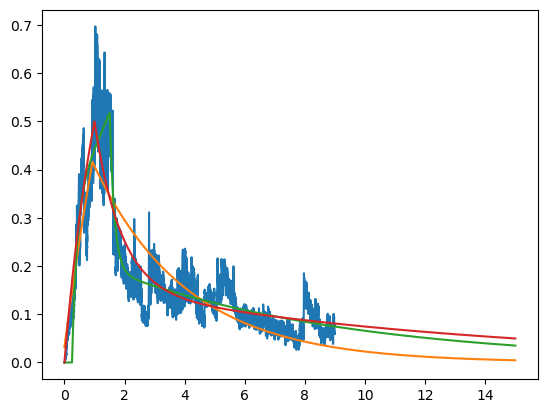

In [471]:
plt.plot(np.arange(skip/2920, 9, 1/2920), tseries[skip:])
plt.plot(np.arange(0, 15, 1/2920), curve_single_day(np.arange(0, 15, 1/2920), fit_single_day[0], fit_single_day[1], fit_single_day[2]))
plt.plot(np.arange(skip/2920, 15, 1/2920), curve_double_day_wd(np.arange(0, 15-skip/2920, 1/2920),
                                                   fit_double_day_wd[0], fit_double_day_wd[1], fit_double_day_wd[2], fit_double_day_wd[3], fit_double_day_wd[4]))
plt.plot(np.arange(0, 15, 1/2920), curve_double_day(np.arange(0, 15, 1/2920),
                                                   fit_double_day[0], fit_double_day[1], fit_double_day[2], fit_double_day[3], ));


## Stack it up and compare to timeseries above ##

In [476]:
pred = discharge[1970] * curve_double_day(np.arange(0, max_year-1970, 1/2920), 
                                          fit_double_day[0], fit_double_day[1], fit_double_day[2], fit_double_day[3],)
for year in range(1970+1, 2050):
    pred[2920*(year-1970):] = (pred[2920*(year-1970):] + 
            discharge[year] * curve_double_day(np.arange(0, max_year-year, 1/2920), 
                                            fit_double_day[0], fit_double_day[1], fit_double_day[2], fit_double_day[3]))

In [508]:
# Min
pred_min = min_discharge[1970] * curve_double_day(np.arange(0, max_year-1970, 1/2920), 
                                          fit_double_day[0], fit_double_day[1], fit_double_day[2], fit_double_day[3],)
for year in range(1970+1, 2050):
    pred_min[2920*(year-1970):] = (pred_min[2920*(year-1970):] + 
            min_discharge[year] * curve_double_day(np.arange(0, max_year-year, 1/2920), 
                                            fit_double_day[0], fit_double_day[1], fit_double_day[2], fit_double_day[3]))

In [505]:
# see div below
pred_slower = discharge[1970] * curve_double_day(np.arange(0, max_year-1970, 1/2920), 
                                          fit_double_day[0], fit_double_day[1]/div, fit_double_day[2], fit_double_day[3]/2,)
for year in range(1970+1, 2050):
    pred_slower[2920*(year-1970):] = (pred_slower[2920*(year-1970):] + 
            discharge[year] * curve_double_day(np.arange(0, max_year-year, 1/2920), 
                                            fit_double_day[0], fit_double_day[1]/div, fit_double_day[2], fit_double_day[3]/2))

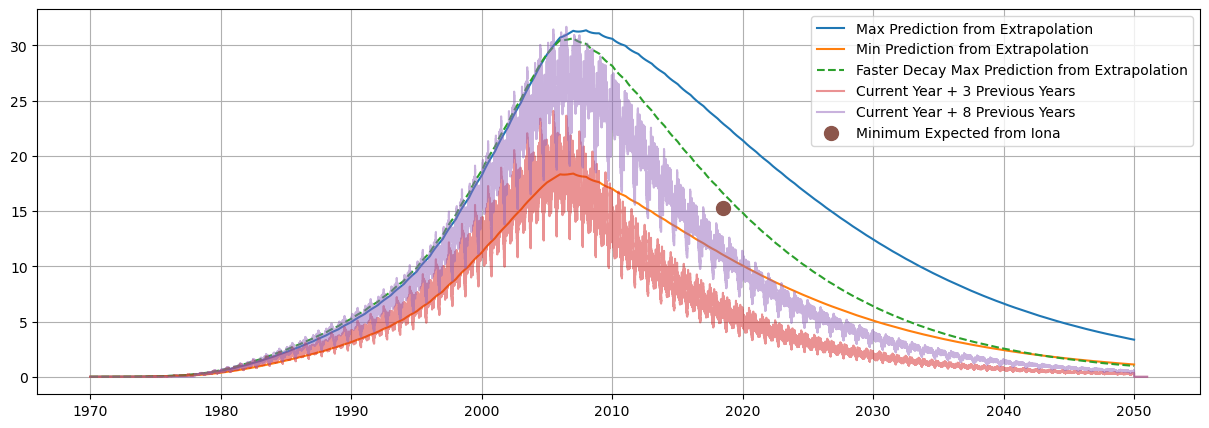

In [510]:
fig, ax = plt.subplots(1, 1, figsize=(15, 5))
ax.plot(np.arange(1970, max_year, 1/2920), pred, label='Max Prediction from Extrapolation')
ax.plot(np.arange(1970, max_year, 1/2920), pred_min, label='Min Prediction from Extrapolation')
ax.plot(np.arange(1970, max_year, 1/2920), pred_slower, '--', label='Faster Decay Max Prediction from Extrapolation')
ax.plot(np.arange(1970, max_year+1, 1/(8*365)), three_values*1e12, label="Current Year + 3 Previous Years", 
            alpha=0.5)
ax.plot(np.arange(1970, max_year+1, 1/(8*365)), eight_values*1e12, label="Current Year + 8 Previous Years", 
            alpha=0.5)
ax.plot([2018.5], [(70.2-31.9)/2.5], 'o', markersize=10, label='Minimum Expected from Iona')
ax.grid()
ax.legend();

## Playing with Faster Decay ##

In [362]:
oneday = copy.copy(pred)

In [366]:
twoday = copy.copy(pred)

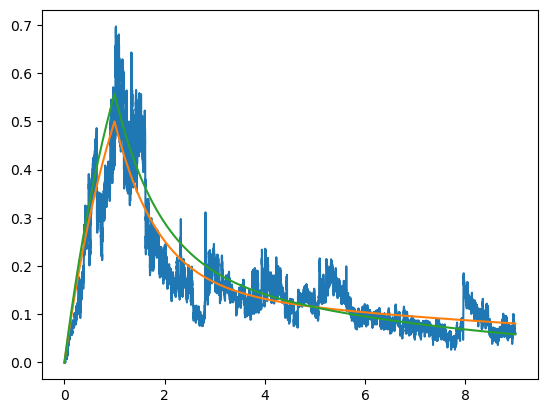

In [504]:
trange = np.arange(0, 9, 1/2920)
div = 1.4
plt.plot(trange, tseries)
plt.plot(trange, curve_double_day(trange, fit_double_day[0], fit_double_day[1], fit_double_day[2], fit_double_day[3]))
plt.plot(trange, curve_double_day(trange, fit_double_day[0], fit_double_day[1]/div, fit_double_day[2], fit_double_day[3]/2))


## How Robust is the Fit ##

In [517]:
fitcheck = np.zeros((10, 4))
for ndays in range(5, 10):
    fitcheck[ndays], cov = curve_fit(curve_double_day, np.arange(0, ndays, 1/2920), tseries[:ndays*2920], p0=[0.6, 0.3, 2, 5])
    print (f'For {ndays}, coefficents are {fitcheck[ndays]}')

For 5, coefficents are [5.93798090e-01 1.23712657e+03 9.50630211e-01 1.07843462e+04]
For 6, coefficents are [5.66771686e-01 2.43937961e+03 9.08124830e-01 1.98546521e+04]
For 7, coefficents are [ 0.56277989  4.01265404  0.92682172 30.6252706 ]
For 8, coefficents are [ 0.49029695  1.80328239  0.85613794 10.64095006]
For 9, coefficents are [ 0.50697685  1.98789182  0.87255098 12.40521322]


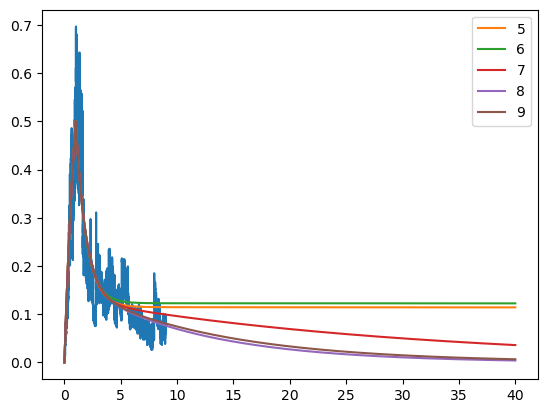

In [521]:
trange = np.arange(0, 40, 1/2920)
plt.plot(trange[:9*2920], tseries)
for ndays in range(5, 10):
    plt.plot(trange, curve_double_day(trange, fitcheck[ndays, 0], fitcheck[ndays, 1], fitcheck[ndays, 2], fitcheck[ndays, 3]), label=ndays)
plt.legend();

8 and 9 are very close